# 35.1 · Brightness constancy and the aperture problem

CPU · Python 3.11–3.13 · seeded teaching experiment

[Open in Google Colab](https://colab.research.google.com/) — use the [ZIP setup workflow](../../docs/colab.md). No model or dataset downloads occur in this notebook.

## Learning Objectives

- Explain brightness constancy and the aperture problem using the chapter's assumptions.
- Translate the worked equation into Python and inspect an implementation.
- Run, visualize and critique a reproducible experiment.

## Prerequisites

[02 · Mathematics for Computer Vision](../../02-mathematics-for-computer-vision/README.md), [13 · Edge and Corner Detection](../../13-edge-and-corner-detection/README.md), [15 · Video Processing](../../15-video-processing/README.md), [18 · Object Tracking](../../18-object-tracking/README.md)

Install the repository before opening this notebook: `python -m pip install -e ".[notebooks,deep,api]"`. The deep/API extras are needed only by chapters that use them.

## 1. Introduction

Optical flow estimates apparent pixel motion between frames. It is a dense or sparse correspondence field, not a semantic object tracker. Brightness constancy and local motion assumptions make the problem tractable but can fail under illumination change, occlusion or large motion.

## 2. Intuition

Brightness constancy assumes a moving scene point keeps approximately the same image intensity. Linearizing this assumption gives one equation for two motion components, so a single pixel is underdetermined. Along a straight edge, only motion perpendicular to the edge is locally observable: this is the aperture problem.

In [1]:
import inspect
import json
import platform
from importlib.metadata import version

import cv2
import numpy as np
from IPython.display import Code, display

from cvzero.course.runner import lab_function, run

CHAPTER = 35
LESSON = 0
SEED = 42
AMOUNT = 1.0
print(
    {
        "python": platform.python_version(),
        "numpy": version("numpy"),
        "opencv": cv2.__version__,
        "device": "cpu",
        "seed": SEED,
    }
)

{'python': '3.12.14', 'numpy': '2.3.5', 'opencv': '4.14.0', 'device': 'cpu', 'seed': 42}


## 3. Mathematical Foundation

$$
I_xu+I_yv+I_t=0
$$

Ix,Iy are spatial intensity derivatives, It the temporal derivative and u,v the small displacement components. If Ix=2, Iy=0 and It=−4, horizontal displacement u=2 satisfies the equation, while v remains unconstrained.

Read the symbols aloud, predict the numerical result, and only then execute the worked example.

## 4. Visual Explanation

The chapter preview shows an actual baseline run. Read every panel title before interpreting color or brightness; some panels show a mask, an error, or a matrix rather than a photograph.

![Measured chapter baseline](../assets/lab-preview.png)

## 5. Basic Implementation

This small calculation isolates the equation from the larger pipeline. Change one number and predict its effect before rerunning.

In [2]:
ix, iy, it = 2.0, 0.0, -4.0
u, v = 2.0, 0.0
residual = ix * u + iy * v + it
assert np.isclose(residual, 0)
print(residual)

0.0


## 6. OpenCV Implementation

The relevant library is selected by the problem: OpenCV for image operations and geometry, scikit-learn for classical learning, PyTorch for differentiable models, and FastAPI for service contracts. OpenCV handles image arrays where it is useful; it does not supply every advanced model.

The reference builds gradient equations and solves least squares. Library comparisons use pyramidal Lucas–Kanade and Farneback; their assumptions and support differ.

The lab function below calls the actual implementation. Inspect its source to see preprocessing, fixed hyperparameters and reported metrics.

In [3]:
display(Code(inspect.getsource(lab_function(CHAPTER)), language="python"))
result = run(CHAPTER, lesson=LESSON, seed=SEED, amount=AMOUNT)
print(json.dumps(result.metrics, indent=2))
print(result.notes)

def optical_flow(lesson=0, seed=42, amount=1.0):
    rng = np.random.default_rng(seed)
    first = (gaussian_filter(rng.random((80, 96)), 1) * 255).astype("uint8")
    shift = min(3.0, 0.5 * amount)
    second = cv2.warpAffine(
        first, np.float32([[1, 0, shift], [0, 1, 0]]), (96, 80), borderMode=cv2.BORDER_REFLECT
    )
    u, v = lucas_kanade_global(first.astype(float) / 255, second.astype(float) / 255)
    flow = cv2.calcOpticalFlowFarneback(first, second, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    points = cv2.goodFeaturesToTrack(first, 30, 0.01, 6)
    moved, status, _ = cv2.calcOpticalFlowPyrLK(first, second, points, None)
    valid = status.ravel().astype(bool)
    sparse = (moved - points)[valid].reshape(-1, 2)
    error = np.linalg.norm(flow[10:-10, 10:-10] - [shift, 0], axis=-1)
    return Result(
        "35 · Brightness constancy and optical flow",
        {
            "First frame": first,
            "Shifted frame": second,
            "Dense horizontal flow (pixels)": flow[..., 0],
            "Dense endpoint error (interior)": error,
        },
        metrics={
            "true_dx": shift,
            "numpy_dx": float(u),
            "numpy_dy": float(v),
            "sparse_mean_dx": float(sparse[:, 0].mean()),
            "dense_mean_endpoint_error": float(error.mean()),
        },
        notes="Lucas–Kanade reference estimates one small global translation. Dense flow is not object identity. Reflect padding is excluded from the error region.",
    )

{
  "true_dx": 0.5,
  "numpy_dx": 0.6035226204828585,
  "numpy_dy": 0.0020205134523039047,
  "sparse_mean_dx": 0.4993315041065216,
  "dense_mean_endpoint_error": 0.010657348641675004
}
Lucas–Kanade reference estimates one small global translation. Dense flow is not object identity. Reflect padding is excluded from the error region.


## 7. From-Scratch Implementation

Read the following reusable reference implementation line by line. Identify input shapes, the main update or reduction, and the boundary/invalid-input policy. Its source lives in `src/cvzero/course/numerics.py`; notebooks reuse it so fixes apply everywhere. Optimized libraries are compared where matching behavior is meaningful.

In [4]:
from cvzero.course.numerics import lucas_kanade_global

display(Code(inspect.getsource(lucas_kanade_global), language="python"))

def lucas_kanade_global(first, second):
    """One global small-translation estimate via brightness-constancy least squares."""
    first, second = gray(first), gray(second)
    gy, gx = np.gradient((first + second) / 2)
    design = np.column_stack([gx[2:-2, 2:-2].ravel(), gy[2:-2, 2:-2].ravel()])
    delta = (second - first)[2:-2, 2:-2].ravel()
    velocity, _, _, _ = np.linalg.lstsq(design, -delta, rcond=None)
    return velocity

## 8. Experiment

Increase translation until the small-motion estimate fails, then compare with pyramidal tracking. Add a uniform brightness offset as a separate failure test.

The run configuration is defined above. `lesson` selects the chapter experiment, `seed` fixes generated data or initialization, and `amount` controls the active experiment's perturbation when supported. Consult the displayed function before changing it: a fixed mathematical example may deliberately ignore a random seed or perturbation. Keep all other settings fixed when testing one hypothesis.

In [5]:
# A second independent seed checks sensitivity; fixed examples may remain identical.
repeat = run(CHAPTER, lesson=LESSON, seed=SEED + 1, amount=AMOUNT)
print(json.dumps({"baseline": result.metrics, "second_seed": repeat.metrics}, indent=2))

{
  "baseline": {
    "true_dx": 0.5,
    "numpy_dx": 0.6035226204828585,
    "numpy_dy": 0.0020205134523039047,
    "sparse_mean_dx": 0.4993315041065216,
    "dense_mean_endpoint_error": 0.010657348641675004
  },
  "second_seed": {
    "true_dx": 0.5,
    "numpy_dx": 0.6033508350830054,
    "numpy_dy": -0.0014913128689777856,
    "sparse_mean_dx": 0.5012531876564026,
    "dense_mean_endpoint_error": 0.010458828969622714
  }
}


## 9. Visualization

These figures are generated by the current run. The second plot uses the second seed. Compare the numerical report with the visible result; a single scalar rarely explains every failure.

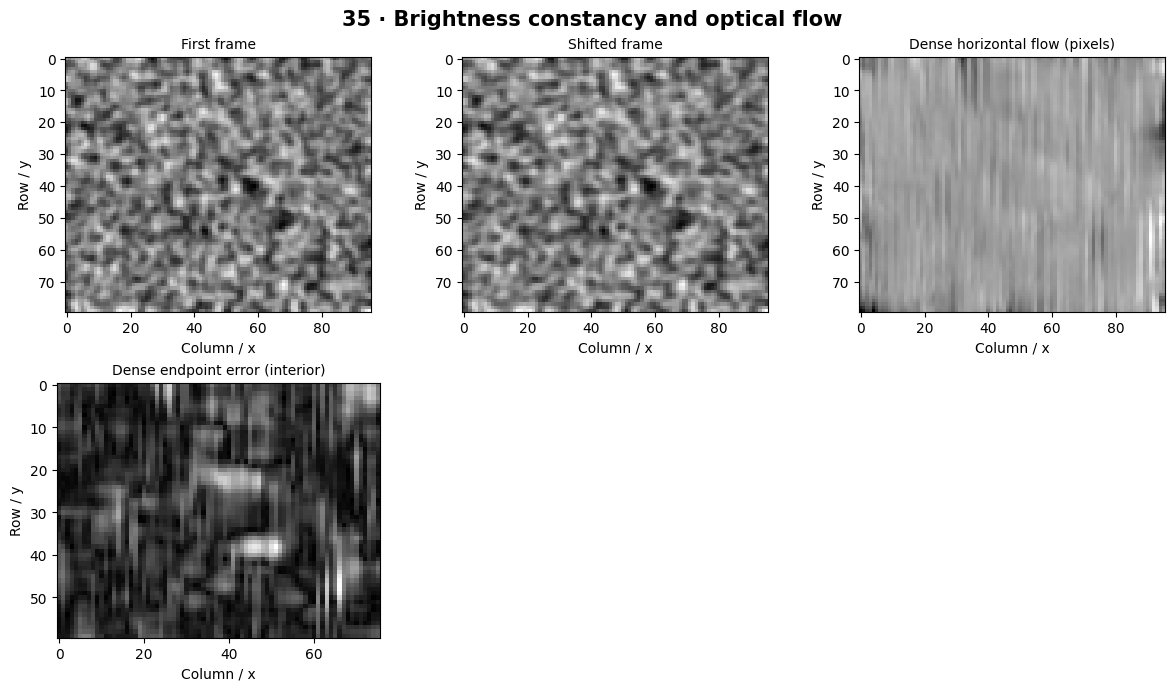

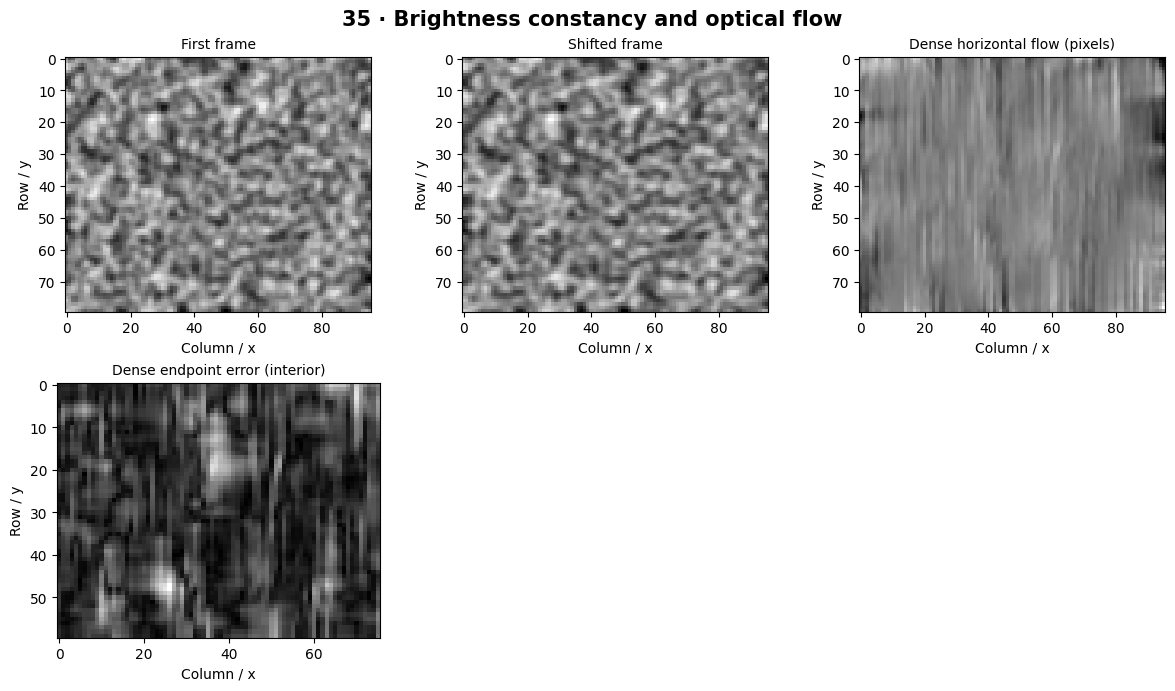

In [6]:
display(result.plot())
display(repeat.plot())

## 10. Real-World Application

The chapter mini project is **Flow Visualization Lab**. Estimate apparent motion and test its assumptions. Start with the generated data so expected geometry or labels are known, then use a separately documented real dataset. Do not transfer synthetic metrics to a real deployment claim.

## 11. Common Mistakes

A colorful flow image can look plausible even when magnitudes are wrong. Use endpoint error against known displacement.

Check shape, dtype, units, split and coordinate conventions before tuning an algorithm.

## 12. Exercises

- **Easy:** Reproduce the worked numerical example by hand and add a second case.
- **Medium:** Increase translation until the small-motion estimate fails, then compare with pyramidal tracking. Add a uniform brightness offset as a separate failure test.
- **Hard:** Create a failure case for one assumption stated in this lesson and propose a measurable remedy.

## 13. Challenge

Build a flow-based motion visualizer that marks poorly conditioned points and separates camera translation from local residual motion.

Write acceptance criteria before coding. No challenge solution is included beside the question.

## 14. Summary

Brightness constancy assumes a moving scene point keeps approximately the same image intensity. Linearizing this assumption gives one equation for two motion components, so a single pixel is underdetermined. Along a straight edge, only motion perpendicular to the edge is locally observable: this is the aperture problem.

**Checkpoint:** explain the mechanism, implement a small case, modify one parameter, debug a failure and apply it to a new example. Record evidence for all five.

## 15. Next Step

Continue with **Lucas–Kanade least squares** in this chapter.

[Primary reference](https://docs.opencv.org/4.x/d4/dee/tutorial_optical_flow.html) · [Chapter exercises](../exercises/beginner.md) · [Mini project](../mini-project/README.md)